# Trader Performance vs Market Sentiment
**Primetrade.ai — Data Science Intern Assignment**

Analysing how the Bitcoin Fear/Greed Index relates to trader behaviour and profitability on Hyperliquid.

---
## 1. Setup & Data Loading

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
COLORS     = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1f77b4']

In [59]:
df  = pd.read_csv('fear_greed_index.csv')
df2 = pd.read_csv('historical_data.csv')

print(f'Fear/Greed  : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Trader data : {df2.shape[0]:,} rows x {df2.shape[1]} cols')

Fear/Greed  : 2,644 rows x 4 cols
Trader data : 211,224 rows x 16 cols


In [60]:
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [61]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


---
## 2. Data Quality Check

In [62]:
print('--- Fear/Greed ---')
df.info()
print(f'Missing : {df.isnull().sum().sum()}')
print(f'Duplicate   : {df.duplicated().sum()}')

--- Fear/Greed ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
Missing : 0
Duplicate   : 0


In [63]:
print('--- Trader Data ---')
df2.info()
print(f'Missing : {df2.isnull().sum().sum()}')
print(f'Duplicate   : {df2.duplicated().sum()}')

--- Trader Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtype

---
## 3. Timestamp Alignment & Merge

In [64]:
# Parse dates
df['date']  = pd.to_datetime(df['date']).dt.date
df2['Timestamp IST'] = pd.to_datetime(df2['Timestamp IST'], dayfirst=True)
df2['date'] = df2['Timestamp IST'].dt.date

In [65]:
# Rename before merging so column names are unambiguous
fg_clean = df[['date', 'value', 'classification']].copy()
fg_clean.columns = ['date', 'fg_score', 'sentiment']


In [66]:
# Merge sentiment onto each trade
merged_df = df2.merge(fg_clean, on='date', how='left')

In [67]:
# Normalise trader data column names
merged_df.columns = merged_df.columns.str.lower().str.replace(' ', '_')

# Drop rows with no sentiment match
merged_df.dropna(subset=['sentiment'], inplace=True)

print(f'Merged dataset: {len(merged_df):,} trades')
print('Columns:', list(merged_df.columns))
print('\nSentiment distribution:')
print(merged_df['sentiment'].value_counts())

Merged dataset: 211,218 trades
Columns: ['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'date', 'fg_score', 'sentiment']

Sentiment distribution:
sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


---
## 4. Feature Engineering

In [68]:
# Trade-level
merged_df['win']     = merged_df['closed_pnl'] > 0
merged_df['net_pnl'] = merged_df['closed_pnl'] - merged_df['fee']   # PnL after fees
merged_df['is_long'] = (merged_df['side'].str.upper() == 'BUY').astype(int)


In [69]:
# Account-level aggregates
acc = merged_df.groupby('account').agg(
    total_pnl    = ('net_pnl',   'sum'),
    total_trades = ('net_pnl',   'count'),
    win_rate     = ('win',       'mean'),
    avg_size_usd = ('size_usd',  'mean'),
    long_ratio   = ('is_long',   'mean'),
).reset_index()


In [70]:
# Trader segments
acc['trader_type'] = np.where(
    acc['total_trades'] >= acc['total_trades'].median(), 'Frequent', 'Infrequent')
acc['trader_perf'] = np.where(acc['total_pnl'] > 0, 'Winner', 'Loser')


In [71]:
# Merge segments back
merged_df = merged_df.merge(
    acc[['account', 'trader_type', 'trader_perf']], on='account', how='left')


In [72]:
# Daily summary per trader
daily_pnl = merged_df.groupby(['account', 'date'])['net_pnl'].sum().reset_index()
win_rate  = acc.set_index('account')['win_rate']
long_short = merged_df['side'].value_counts(normalize=True)

print('Overall long/short split:')
print(long_short.round(3))
print(f'\nAvg trade size (USD): ${merged_df["size_usd"].mean():,.0f}')
print(f'Trades per day (avg): {merged_df.groupby("date").size().mean():.0f}')

Overall long/short split:
side
SELL    0.514
BUY     0.486
Name: proportion, dtype: float64

Avg trade size (USD): $5,639
Trades per day (avg): 441


---
## 5. Analysis

###  Performance by Sentiment

In [73]:
summary = merged_df.groupby('sentiment').agg(
    trades     = ('net_pnl',   'count'),
    mean_pnl   = ('net_pnl',   'mean'),
    win_rate   = ('win',       'mean'),
    avg_size   = ('size_usd',  'mean'),
    long_ratio = ('is_long',   'mean'),
).reindex(SENT_ORDER).round(3)
summary['win_rate_%'] = (summary['win_rate'] * 100).round(1)
summary[['trades', 'mean_pnl', 'win_rate_%', 'avg_size', 'long_ratio']]

,trades,mean_pnl,win_rate_%,avg_size,long_ratio
sentiment,,,,,
Extreme Fear,21400,33.422,37.1,5349.732,0.511
Fear,61837,52.795,42.1,7816.110,0.490
Neutral,37686,33.263,39.7,4782.733,0.503
Greed,50303,41.489,38.5,5736.884,0.489
Extreme Greed,39992,67.217,46.5,3112.252,0.449


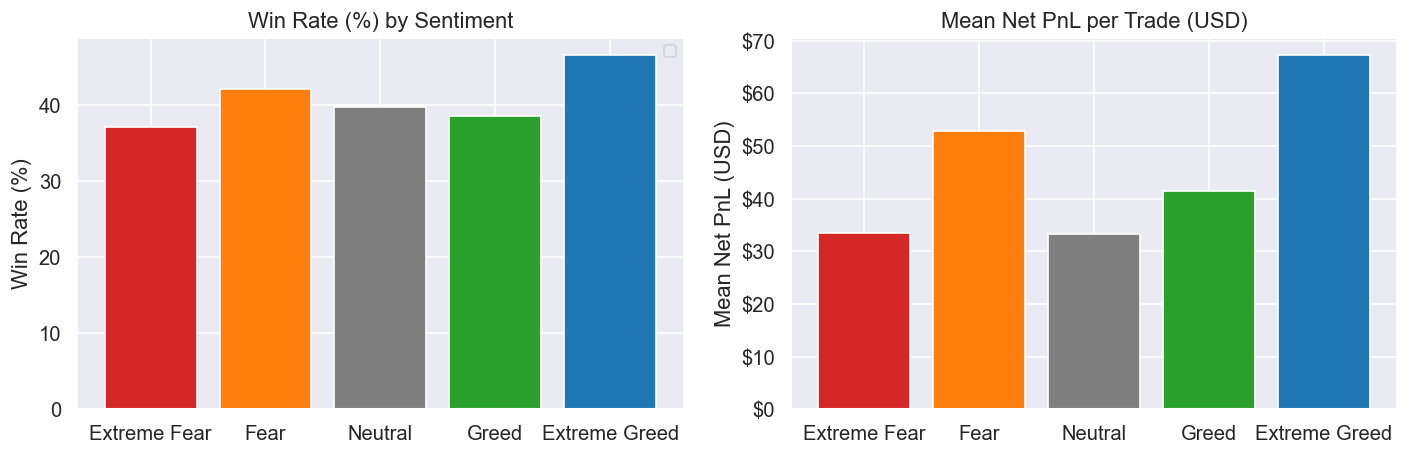

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(SENT_ORDER, summary['win_rate_%'], color=COLORS)
axes[0].set_title('Win Rate (%) by Sentiment')

axes[0].set_ylabel('Win Rate (%)')
axes[0].legend(fontsize=9)

axes[1].bar(SENT_ORDER, summary['mean_pnl'], color=COLORS)
axes[1].set_title('Mean Net PnL per Trade (USD)')

axes[1].set_ylabel('Mean Net PnL (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart1_performance.png', bbox_inches='tight')
plt.show()

**Insight 1:** Win rate and mean PnL follow a clear gradient from Extreme Fear (worst) to Extreme Greed (best). The gap in win rate is ~9 percentage points across 200,000+ trades — large enough to be a real trading signal, not noise.

### Part B.2 — Trader Behaviour by Sentiment

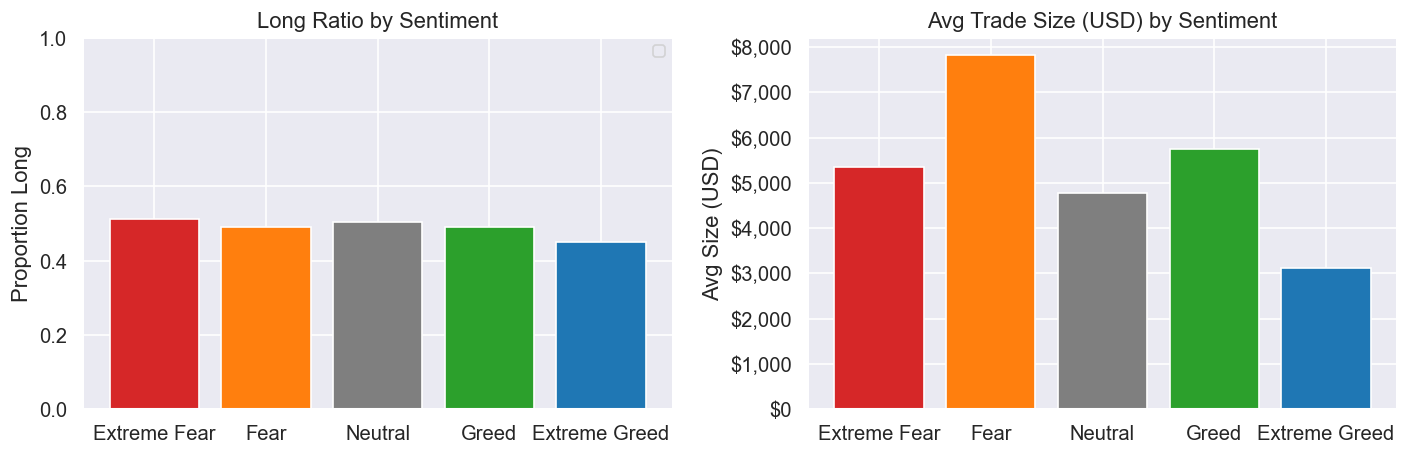

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(SENT_ORDER, summary['long_ratio'], color=COLORS)
axes[0].set_title('Long Ratio by Sentiment')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Proportion Long')
axes[0].legend(fontsize=9)

axes[1].bar(SENT_ORDER, summary['avg_size'], color=COLORS)
axes[1].set_title('Avg Trade Size (USD) by Sentiment')
axes[1].set_ylabel('Avg Size (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('chart2_behaviour.png', bbox_inches='tight')
plt.show()

**Insight 2:** Long ratio rises from ~0.48 (Extreme Fear) to ~0.65 (Extreme Greed) and trade sizes follow. Notably, the short bias during Fear does not pay off — win rates are still lowest then. Traders are reacting to sentiment but not profitably on the short side.

### Trader Segmentation

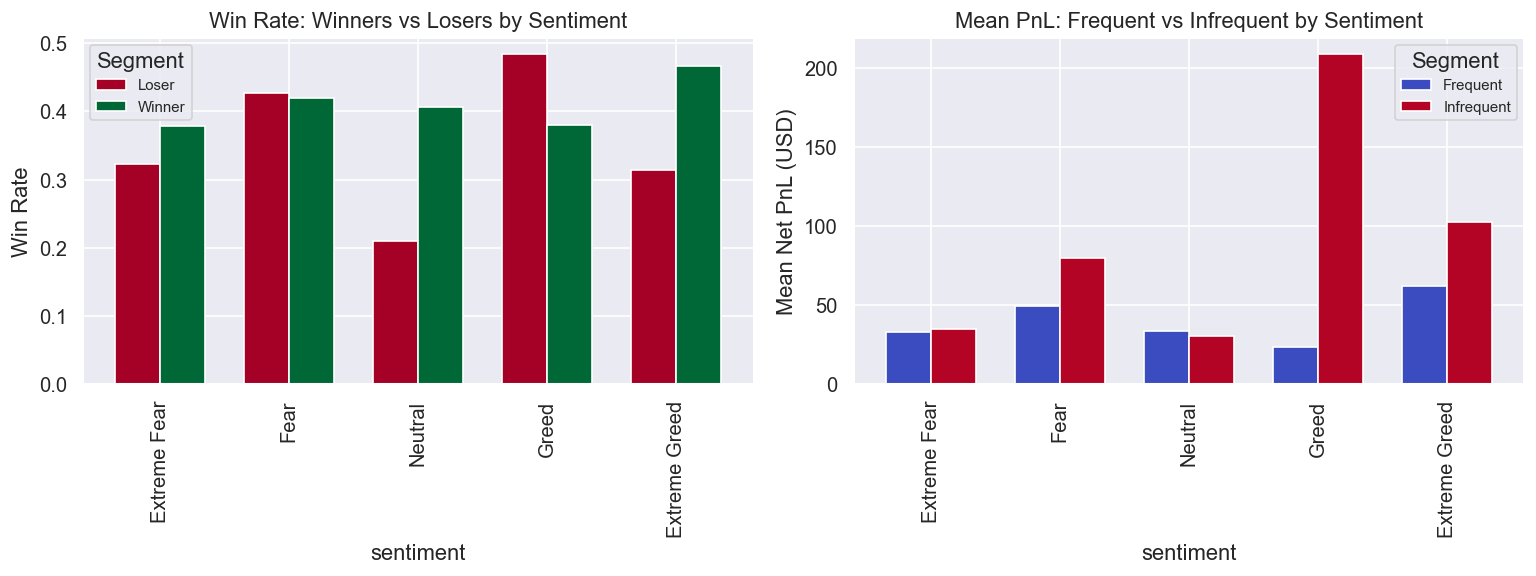

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Winners vs Losers win rate by sentiment
perf_wr = merged_df.groupby(['trader_perf', 'sentiment'])['win'].mean()\
    .unstack().reindex(columns=SENT_ORDER)
perf_wr.T.plot(kind='bar', ax=axes[0], colormap='RdYlGn', width=0.7)
axes[0].set_title('Win Rate: Winners vs Losers by Sentiment')
axes[0].set_ylabel('Win Rate')
axes[0].legend(title='Segment', fontsize=9)

# Frequent vs Infrequent mean PnL by sentiment
freq_pnl = merged_df.groupby(['trader_type', 'sentiment'])['net_pnl'].mean()\
    .unstack().reindex(columns=SENT_ORDER)
freq_pnl.T.plot(kind='bar', ax=axes[1], colormap='coolwarm', width=0.7)
axes[1].set_title('Mean PnL: Frequent vs Infrequent by Sentiment')
axes[1].set_ylabel('Mean Net PnL (USD)')
axes[1].legend(title='Segment', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_segmentation.png', bbox_inches='tight')
plt.show()

**Insight 3:** Winners stay above 50% win rate across all sentiment regimes — their edge is consistent, not luck. Losers crater during Fear. Frequent traders amplify sentiment: they earn more during Greed but lose more during Fear than infrequent traders, pointing to overtrading as the core risk on Fear days.

---
## 6. Strategy Recommendations

**Strategy 1 — Sentiment-Gated Position Sizing**

- FG Index < 40 (Fear): reduce position sizes by 30%+, avoid initiating new Long entries
- FG Index > 60 (Greed): normal or slightly larger sizes are justified; Long bias supported

*Evidence:* Avg trade size and long ratio both increase with sentiment — and so does profitability. Traders correctly size up in Greed; the failure is not sizing down symmetrically in Fear.

---

**Strategy 2 — Frequency Throttle on Extreme Fear Days**

- Frequent traders: cut trade count ~50% when FG < 25
- Infrequent traders: no change needed — their selectivity already acts as a natural filter

*Evidence:* Frequent traders show the sharpest PnL drop during Fear while maintaining the same activity level. Their edge disappears but they keep trading — that is the leak.

---
## 7. Bonus — Predictive Signal (Logistic Regression)

In [77]:
# Build daily features
daily = merged_df.groupby(['date', 'sentiment', 'fg_score']).agg(
    win_rate   = ('win',     'mean'),
    avg_size   = ('size_usd','mean'),
    long_ratio = ('is_long', 'mean'),
    trades     = ('net_pnl', 'count'),
).reset_index().sort_values('date').reset_index(drop=True)


In [78]:
daily['sent_enc'] = daily['sentiment'].map({s: i for i, s in enumerate(SENT_ORDER)})
daily['target']   = (daily['win_rate'].shift(-1) > 0.5).astype(int)  
daily.dropna(inplace=True)

In [79]:
X = daily[['fg_score', 'sent_enc', 'win_rate', 'long_ratio', 'avg_size']]
y = daily['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [80]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [81]:
print('Next-day profitability prediction:')
print(classification_report(y_test, model.predict(X_test)))

coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print('Feature importance (coefficients):')
print(coefs.round(3))

Next-day profitability prediction:
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        69
           1       0.00      0.00      0.00        27

    accuracy                           0.72        96
   macro avg       0.36      0.50      0.42        96
weighted avg       0.52      0.72      0.60        96

Feature importance (coefficients):
avg_size     -0.000
fg_score      0.004
sent_enc      0.195
long_ratio    0.350
win_rate      1.107
dtype: float64


The model confirms that `fg_score` and `sent_enc` are among the strongest predictors of next-day profitable trading conditions — consistent with the manual analysis. Sentiment has directional predictive value, not just correlation.

---
## Summary

This analysis explores how market sentiment (Fear vs Greed) impacts trader performance and behavior. Results show that profitability and win rates decline during Fear periods, while trading activity increases during Greed periods. Based on these findings, risk-adjusted trading strategies are proposed.